In [1]:
# Import & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import time

BASE_PATH = r'D:\Jupyter\MLOps_Gold\\'
DATA_PATH = BASE_PATH + 'data\\'
VISUAL_PATH = BASE_PATH + 'visuals\\'
MODEL_PATH = BASE_PATH + 'models\\'

os.makedirs(VISUAL_PATH, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)

print("Setup selesai!")

Setup selesai!


In [2]:
#  Load Data & Split
df_norm = pd.read_parquet(DATA_PATH + 'data_clean_normalized.parquet')
feature_cols = [c for c in df_norm.columns if c != 'Target']

train_size = int(len(df_norm) * 0.7)
val_size = int(len(df_norm) * 0.15)

train_df = df_norm.iloc[:train_size]
val_df = df_norm.iloc[train_size:train_size+val_size]
test_df = df_norm.iloc[train_size+val_size:]

print(f"Data berhasil dimuat!")
print(f"Total: {len(df_norm):,} baris")
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print(f"Train: {train_df.index.min().date()} s/d {train_df.index.max().date()}")
print(f"Val  : {val_df.index.min().date()} s/d {val_df.index.max().date()}")
print(f"Test : {test_df.index.min().date()} s/d {test_df.index.max().date()}")

Data berhasil dimuat!
Total: 11,381,288 baris
Train: 7,966,901 | Val: 1,707,193 | Test: 1,707,194
Train: 2004-06-11 s/d 2019-08-04
Val  : 2019-08-04 s/d 2022-11-02
Test : 2022-11-02 s/d 2026-01-30


In [3]:
# Persiapan Data XGBoost
X_train = train_df[feature_cols].values
y_train = train_df['Target'].values

X_val = val_df[feature_cols].values
y_val = val_df['Target'].values

X_test = test_df[feature_cols].values
y_test = test_df['Target'].values

print(f"Data siap!")
print(f"Shape X_train: {X_train.shape}")
print(f"Shape X_val  : {X_val.shape}")
print(f"Shape X_test : {X_test.shape}")

Data siap!
Shape X_train: (7966901, 24)
Shape X_val  : (1707193, 24)
Shape X_test : (1707194, 24)


In [4]:
# Build & Train XGBoost
import xgboost as xgb

model_xgb = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    device='cuda',
    early_stopping_rounds=20,
    eval_metric='rmse',
    random_state=42,
    verbosity=1
)

start_time = time.time()

model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

elapsed = time.time() - start_time
print(f"\nTraining XGBoost selesai: {elapsed/60:.1f} menit")

[0]	validation_0-rmse:0.32503
[50]	validation_0-rmse:0.03598
[100]	validation_0-rmse:0.02493
[150]	validation_0-rmse:0.02458
[200]	validation_0-rmse:0.02447
[250]	validation_0-rmse:0.02439
[300]	validation_0-rmse:0.02432
[350]	validation_0-rmse:0.02426
[400]	validation_0-rmse:0.02421
[450]	validation_0-rmse:0.02417
[499]	validation_0-rmse:0.02413

Training XGBoost selesai: 0.7 menit


In [5]:
# Evaluasi
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred_xgb = model_xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

mask = np.abs(y_test) > 0.01
mape = np.mean(np.abs((y_test[mask] - y_pred_xgb[mask]) / y_test[mask])) * 100
da = np.mean(np.sign(np.diff(y_test)) == np.sign(np.diff(y_pred_xgb))) * 100

print("=" * 50)
print("EVALUASI XGBOOST")
print("=" * 50)
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAPE : {mape:.4f}%")
print(f"Directional Accuracy: {da:.2f}%")
print("=" * 50)

D:\Jupyter\env_gpu\lib\site-packages\xgboost\core.py:751: UserWarning: [03:31:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


EVALUASI XGBOOST
MAE  : 0.011483
RMSE : 0.023757
MAPE : 5.6602%
Directional Accuracy: 34.88%


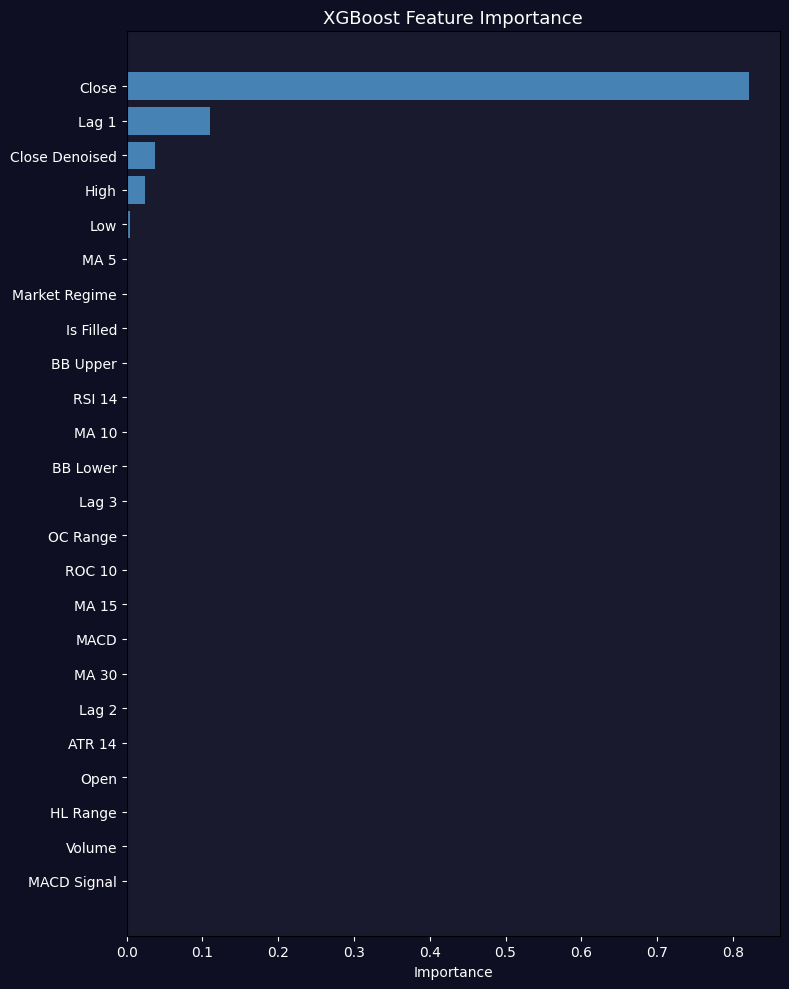

Feature importance berhasil!


In [6]:
# Feature Importance
importances = model_xgb.feature_importances_
fi_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(fi_df['Feature'], fi_df['Importance'], color='steelblue')
ax.set_title('XGBoost Feature Importance', color='white', fontsize=13)
ax.set_xlabel('Importance', color='white')
ax.set_facecolor('#1a1a2e')
ax.tick_params(colors='white')
fig.patch.set_facecolor('#0f0f23')
plt.tight_layout()
plt.savefig(VISUAL_PATH + 'xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance berhasil!")

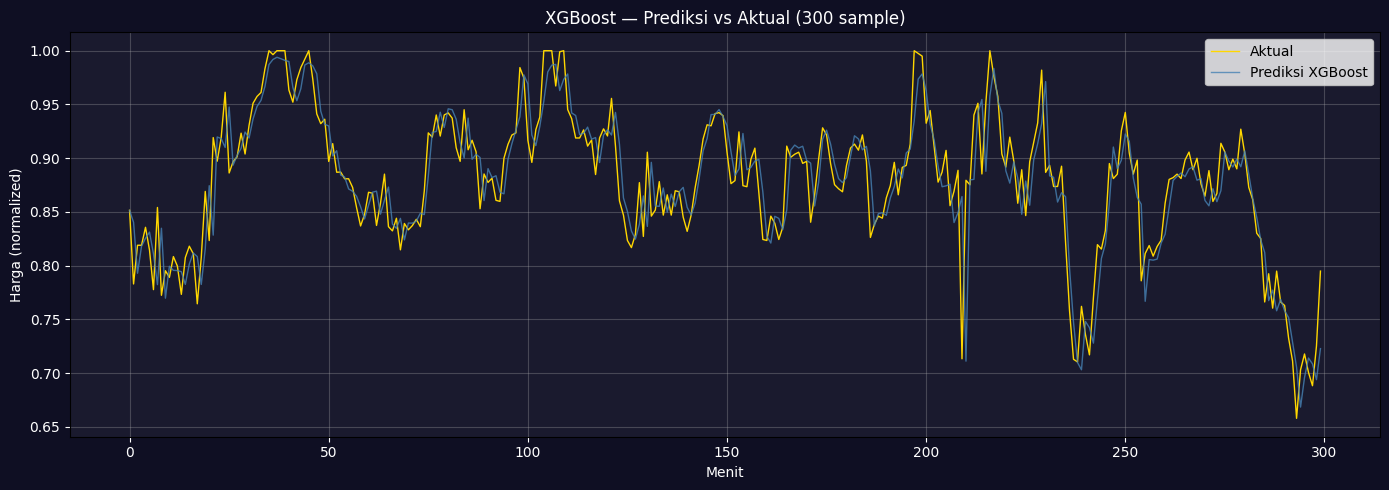

Visualisasi prediksi berhasil!


In [7]:
# Visualisasi Prediksi vs Aktual
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(y_test[:300], label='Aktual', color='gold', linewidth=1)
ax.plot(y_pred_xgb[:300], label='Prediksi XGBoost', color='steelblue', linewidth=1, alpha=0.8)

ax.set_title('XGBoost — Prediksi vs Aktual (300 sample)', color='white')
ax.set_xlabel('Menit', color='white')
ax.set_ylabel('Harga (normalized)', color='white')
ax.legend()
ax.set_facecolor('#1a1a2e')
ax.grid(True, alpha=0.3)
ax.tick_params(colors='white')

fig.patch.set_facecolor('#0f0f23')
plt.tight_layout()
plt.savefig(VISUAL_PATH + 'xgb_prediction.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualisasi prediksi berhasil!")

In [8]:
# Save Model & Hasil
model_xgb.save_model(MODEL_PATH + 'model_xgb.json')
print("Model disimpan sebagai .json")

import joblib
joblib.dump(model_xgb, MODEL_PATH + 'model_xgb.pkl')
print("Model disimpan sebagai .pkl")

# Save hasil evaluasi
results_xgb = {
    'Model': 'XGBoost',
    'MAE': float(mae),
    'RMSE': float(rmse),
    'MAPE (%)': float(mape),
    'Directional Accuracy (%)': float(da)
}

with open(MODEL_PATH + 'results_xgb.json', 'w') as f:
    json.dump(results_xgb, f)

print("=" * 50)
print("SUMMARY XGBOOST")
print("=" * 50)
print(f"Model    : XGBoost (n_estimators=500, max_depth=6)")
print(f"MAE      : {mae:.6f}")
print(f"RMSE     : {rmse:.6f}")
print(f"MAPE     : {mape:.4f}%")
print(f"Dir. Acc : {da:.2f}%")
print(f"\nSemua file disimpan di: {MODEL_PATH}")
print("=" * 50)

Model disimpan sebagai .json
Model disimpan sebagai .pkl
SUMMARY XGBOOST
Model    : XGBoost (n_estimators=500, max_depth=6)
MAE      : 0.011483
RMSE     : 0.023757
MAPE     : 5.6602%
Dir. Acc : 34.88%

Semua file disimpan di: D:\Jupyter\MLOps_Gold\\models\
